# Google Brain Ventilator Pressure Prediction - LightGBM ベースライン

**目的**: 人工呼吸器の吸気相における肺内圧（pressure）を予測する。

**ノートブックの流れ**（`google-brain-lightgbm-optuna` と同様の構成）  
分析設計 → データ前処理 → EDA → 特徴量エンジニアリング → データセット作成 → Optuna によるハイパーパラメータ探索（参考コード・コメントアウト）→ モデル学習（LightGBM / `LGBMRegressor`）→ 評価 → 特徴量重要度 → 提出用ファイル作成

---
## 1. 分析設計

コンペで何を予測し、どの指標で評価するかを明確にします。

| 項目 | 内容 | 選んだ根拠 |
|------|------|------------|
| **目的変数** | `pressure`（気道圧） | コンペの公式説明および Data タブの説明で「predict the pressure in the respiratory circuit」とされているため。 |
| **目的変数の種類** | **連続値（回帰）** | pressure は実数値（例: -1.895 ~ 64.0 程度）で、離散ラベルではなく連続的な物理量であるため。2値・カテゴリではない。 |
| **評価指標** | **MAE（Mean Absolute Error）** | コンペの「Evaluation」で MAE が指定されているため。予測圧と正解圧の絶対誤差の平均を最小化する。 |

**タスクの整理**  
- 時系列データ: 1 呼吸（breath）あたり 80 ステップ。各ステップで `time_step`, `u_in`, `u_out` が与えられ、そのステップの `pressure` を予測する。
- テストでは `pressure` が欠けているため、同じ形式の特徴量から pressure を予測して提出する。

---
## 2. ライブラリの読み込みとパス設定

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb
# import optuna  # セクション7のパラメータ探索を使うときに有効化
import warnings

warnings.filterwarnings("ignore")

# Kaggle 環境専用パス（コンペの Data を追加したときのパス）
INPUT_DIR = "/kaggle/input/ventilator-pressure-prediction"
OUTPUT_DIR = "/kaggle/working"
TRAIN_PATH = f"{INPUT_DIR}/train.csv"
TEST_PATH = f"{INPUT_DIR}/test.csv"
SAMPLE_SUBMISSION_PATH = f"{INPUT_DIR}/sample_submission.csv"
SUBMISSION_PATH = f"{OUTPUT_DIR}/submission.csv"

TARGET = "pressure"
ID_COL = "id"

pd.set_option("display.max_columns", 20)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")
%matplotlib inline

---
## 3. データ前処理

データの読み込み、型・欠損の確認、breath 単位でソートして時系列の並びをそろえます。

In [2]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

print("【訓練データ】 行数:", len(train), ", 列数:", len(train.columns))
print("【テストデータ】 行数:", len(test), ", 列数:", len(test.columns))
print()
print("訓練データ 先頭5行:")
train.head()

【訓練データ】 行数: 6036000 , 列数: 8
【テストデータ】 行数: 4024000 , 列数: 7

訓練データ 先頭5行:


,id,breath_id,R,C,time_step,u_in,u_out,pressure
0,1,1,20,50,0.000000,0.083334,0,5.837492
1,2,1,20,50,0.033652,18.383041,0,5.907794
2,3,1,20,50,0.067514,22.509278,0,7.876254
3,4,1,20,50,0.101542,22.808822,0,11.742872
4,5,1,20,50,0.135756,25.355850,0,12.234987


In [3]:
train.info()
print()
print("欠損値:")
print(train.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6036000 entries, 0 to 6035999
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   id         int64  
 1   breath_id  int64  
 2   R          int64  
 3   C          int64  
 4   time_step  float64
 5   u_in       float64
 6   u_out      int64  
 7   pressure   float64
dtypes: float64(3), int64(5)
memory usage: 368.4 MB

欠損値:
id           0
breath_id    0
R            0
C            0
time_step    0
u_in         0
u_out        0
pressure     0
dtype: int64


In [4]:
# breath_id と time_step でソート（時系列の順序を保つ）
train = train.sort_values(["breath_id", "time_step"]).reset_index(drop=True)
test = test.sort_values(["breath_id", "time_step"]).reset_index(drop=True)
print("breath_id, time_step でソート済み")

breath_id, time_step でソート済み


---
## 4. EDA（探索的データ分析）

`google-brain-lightgbm-optuna` と同様に、要約統計・カテゴリ（`R`, `C`）の件数・主要変数の分布・テスト先頭行を確認します。

In [5]:
train.describe()

,id,breath_id,R,C,time_step,u_in,u_out,pressure
count,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06
mean,3.018000e+06,6.283886e+04,2.703618e+01,2.608072e+01,1.307225e+00,7.321615e+00,6.204493e-01,1.122041e+01
std,1.742443e+06,3.633526e+04,1.959549e+01,1.715231e+01,7.659778e-01,1.343470e+01,4.852752e-01,8.109703e+00
min,1.000000e+00,1.000000e+00,5.000000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,-1.895744e+00
25%,1.509001e+06,3.137700e+04,5.000000e+00,1.000000e+01,6.428995e-01,3.936623e-01,0.000000e+00,6.329607e+00
50%,3.018000e+06,6.276550e+04,2.000000e+01,2.000000e+01,1.308123e+00,4.386146e+00,1.000000e+00,7.032628e+00
75%,4.527000e+06,9.430100e+04,5.000000e+01,5.000000e+01,1.965502e+00,4.983895e+00,1.000000e+00,1.364103e+01
max,6.036000e+06,1.257490e+05,5.000000e+01,5.000000e+01,2.937238e+00,1.000000e+02,1.000000e+00,6.482099e+01


In [6]:
print("欠損値（訓練）:")
print(train.isnull().sum())
print()
print("breath_id のユニーク数:", train["breath_id"].nunique())
print("各 breath のステップ数（先頭数件）:")
print(train["breath_id"].value_counts().head())

欠損値（訓練）:
id           0
breath_id    0
R            0
C            0
time_step    0
u_in         0
u_out        0
pressure     0
dtype: int64

breath_id のユニーク数: 75450
各 breath のステップ数（先頭数件）:
breath_id
125749    80
1         80
2         80
3         80
4         80
Name: count, dtype: int64


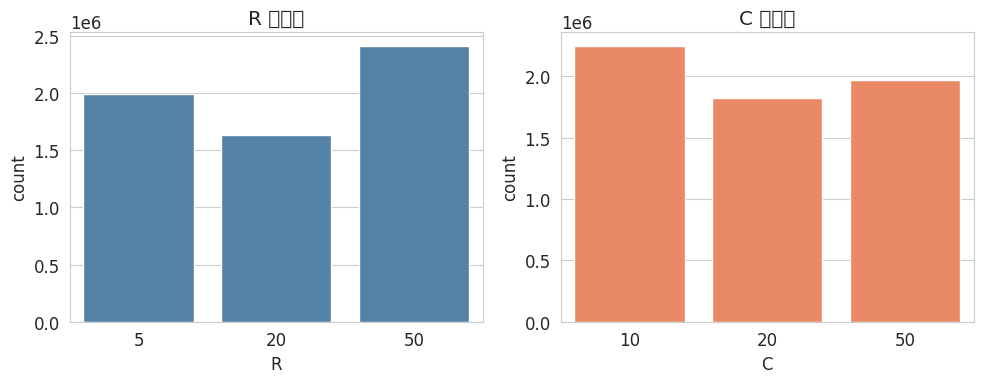

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(data=train, x="R", ax=axes[0], color="steelblue")
axes[0].set_title("R の件数")
sns.countplot(data=train, x="C", ax=axes[1], color="coral")
axes[1].set_title("C の件数")
plt.tight_layout()
plt.show()

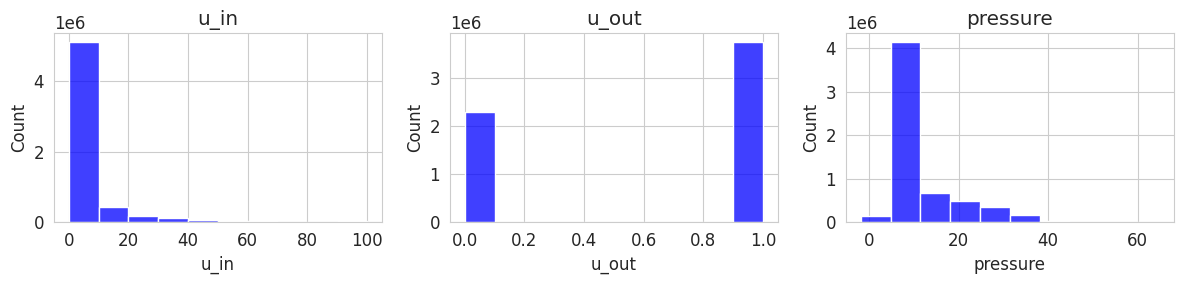

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
sns.histplot(train["u_in"], bins=10, kde=False, color="blue", ax=axes[0])
axes[0].set_title("u_in")
sns.histplot(train["u_out"], bins=10, kde=False, color="blue", ax=axes[1])
axes[1].set_title("u_out")
sns.histplot(train[TARGET], bins=10, kde=False, color="blue", ax=axes[2])
axes[2].set_title(TARGET)
plt.tight_layout()
plt.show()

In [9]:
print("テストデータ 先頭5行:")
test.head()

テストデータ 先頭5行:


,id,breath_id,R,C,time_step,u_in,u_out
0,1,0,5,20,0.000000,0.000000,0
1,2,0,5,20,0.031904,7.515046,0
2,3,0,5,20,0.063827,14.651675,0
3,4,0,5,20,0.095751,21.230610,0
4,5,0,5,20,0.127644,26.320956,0


---
## 5. 特徴量エンジニアリング

`google-brain-lightgbm-optuna` と同様に、**同一 breath 内**の `u_in` について累積和（`u_in_cumsum`）と 2 ステップラグ（`u_in_lag`）を追加します。  
※ 元カーネルは全体に対する `shift` ですが、呼吸をまたがないよう `breath_id` ごとに計算しています。

In [10]:
train["u_in_cumsum"] = train.groupby("breath_id")["u_in"].cumsum()
test["u_in_cumsum"] = test.groupby("breath_id")["u_in"].cumsum()

train["u_in_lag"] = train.groupby("breath_id")["u_in"].shift(2).fillna(0)
test["u_in_lag"] = test.groupby("breath_id")["u_in"].shift(2).fillna(0)

print("特徴量追加後の列（訓練）:", list(train.columns))

特徴量追加後の列（訓練）: ['id', 'breath_id', 'R', 'C', 'time_step', 'u_in', 'u_out', 'pressure', 'u_in_cumsum', 'u_in_lag']


---
## 6. データセット作成

**施策1・方法B**: `u_out=1`（呼気相）の行は**訓練に使わない**。`u_out=0`（吸気相）の行だけから `X`, `y` を作ります（`スコアアップ施策評価とロードマップ.md` と同じ考え方）。

`id`, `breath_id`, `pressure` を除いた特徴量を `X` とし、目的変数を `y` とします。訓練データは吸気相のみのため `u_out` は常に 0 ですが、テストで吸気行を予測するときの特徴として列はそのまま残します。

In [11]:
train_insp = train[train["u_out"] == 0].copy()
X = train_insp.drop(["id", "breath_id", "pressure"], axis=1)
y = train_insp[TARGET]
X_test = test.drop(["id", "breath_id"], axis=1)

print("施策1（方法B）: 訓練は u_out=0（吸気相）のみ。除外した呼気行数:", (train["u_out"] == 1).sum())
print("特徴量列:", list(X.columns))
print("X shape:", X.shape)
print("X_test shape:", X_test.shape)

特徴量列: ['R', 'C', 'time_step', 'u_in', 'u_out', 'u_in_cumsum', 'u_in_lag']
X shape: (6036000, 7)
X_test shape: (4024000, 7)


---
## 7. ハイパーパラメータ探索（Optuna）

（参考）`train_test_split` で切り分けた検証 MAE を最小化するように `LGBMRegressor` のハイパーパラメータを探索するコード例です。  
現状は**下のセルはコメントアウト済み**です。`import optuna` を有効化し、セル内のコメントを外して `study.optimize` を実行してください。

In [12]:
# def objective(trial):
#     X_train, X_valid, y_train, y_valid = train_test_split(
#         X, y, train_size=0.8, test_size=0.2, random_state=0
#     )
#     params = {
#         "objective": "regression",
#         "metric": "mae",
#         "boosting_type": "gbdt",
#         "n_estimators": 1000,
#         "random_state": 42,
#         "learning_rate": trial.suggest_categorical(
#             "learning_rate", [0.006, 0.008, 0.01, 0.014, 0.017, 0.02]
#         ),
#         "subsample": trial.suggest_float("subsample", 0.4, 1.0, log=True),
#         "subsample_freq": trial.suggest_float("subsample_freq", 0.4, 1.0, log=True),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
#         "min_child_weight": trial.suggest_int("min_child_weight", 5, 256),
#         "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
#         "bagging_fraction": trial.suggest_float("bagging_fraction", 0.4, 1.0),
#         "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
#     }
#     model = lgb.LGBMRegressor(**params)
#     model.fit(X_train, y_train)
#     preds = model.predict(X_valid)
#     return mean_absolute_error(y_valid, preds)
#
#
# # study = optuna.create_study(direction="minimize")
# # study.optimize(objective, n_trials=10)
# # print("Number of finished trials:", len(study.trials))
# # print("Best trial:", study.best_trial.params)

---
## 8. モデル学習（LightGBM）

`train_test_split` で学習・検証に分割し、`LGBMRegressor` を学習します（**検証も吸気相の行のみ**）。ハイパーパラメータは `google-brain-lightgbm-optuna` で示されている **探索後の一例**（カーネル内の固定値）をそのまま利用します。独自に Optuna を回した場合は `study.best_trial.params` を反映してください。

**サンプリング系パラメータ**: `subsample` / `subsample_freq` と `bagging_fraction` / `bagging_freq` を同時に渡すと、LightGBM は bagging 側を優先し、もう一方を無視して警告が出ます。本ノートでは警告を避けるため **bagging のみ**指定しています（実効は従来どおり bagging 側）。

学習後は **セクション9** で特徴量重要度（gain / split）を確認します。

In [13]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=0
)

lgb_params = {
    "objective": "regression",
    "metric": "mae",
    "boosting_type": "gbdt",
    "n_estimators": 1000,
    "random_state": 42,
    "learning_rate": 0.017,
    "colsample_bytree": 0.7981147731267384,
    "reg_alpha": 0.29250836566881794,
    "reg_lambda": 0.0032438602599939702,
    "min_child_weight": 134,
    "min_child_samples": 26,
    "bagging_fraction": 0.6263245217964235,
    "bagging_freq": 1,
    "verbose": -1,
}

model = lgb.LGBMRegressor(**lgb_params)
model.fit(X_train, y_train)

LGBMRegressor(bagging_fraction=0.6263245217964235, bagging_freq=1,
              colsample_bytree=0.7981147731267384, learning_rate=0.017,
              metric='mae', min_child_samples=26, min_child_weight=134,
              n_estimators=1000, objective='regression', random_state=42,
              reg_alpha=0.29250836566881794, reg_lambda=0.0032438602599939702,
              verbose=-1)

In [14]:
pred_valid = model.predict(X_valid)
print("検証データ MAE:", mean_absolute_error(y_valid, pred_valid))

検証データ MAE: 0.8796306876552868


---
## 9. 特徴量重要度

学習済みモデルについて、LightGBM の **gain**（分岐による損失の改善合計）と **split**（特徴が使われた回数）を集計します。  
`LGBMRegressor.feature_importances_` は既定で **split** 重要度（分岐に使われた回数ベース）です。解釈のため **gain**（損失改善への寄与）も併記します。

特徴量重要度（gain 降順）:
    feature         gain  split  gain_pct
  time_step 2.419428e+09   8588 42.474076
u_in_cumsum 1.751081e+09   6295 30.740964
   u_in_lag 7.472592e+08   4406 13.118447
          C 3.070753e+08   3246  5.390835
          R 3.038107e+08   3553  5.333523
       u_in 8.468773e+07   3559  1.486728
      u_out 8.290466e+07    353  1.455426

model.feature_importances_（LightGBM では既定で split 重要度と一致）:
time_step      8588
u_in_cumsum    6295
u_in_lag       4406
u_in           3559
R              3553
C              3246
u_out           353


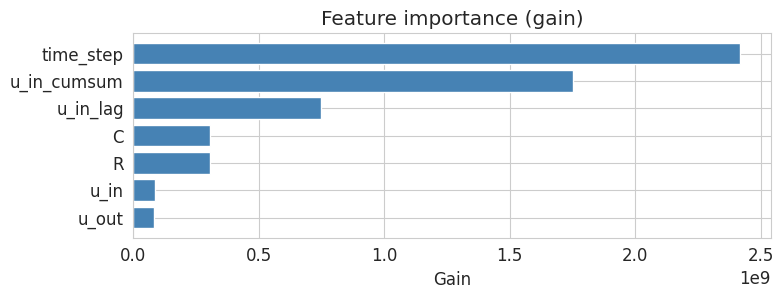

In [15]:
booster = model.booster_
imp_df = pd.DataFrame({
    "feature": X.columns,
    "gain": booster.feature_importance(importance_type="gain"),
    "split": booster.feature_importance(importance_type="split"),
})
imp_df["gain_pct"] = 100 * imp_df["gain"] / imp_df["gain"].sum()
imp_df = imp_df.sort_values("gain", ascending=False).reset_index(drop=True)

print("特徴量重要度（gain 降順）:")
print(imp_df.to_string(index=False))
print()
print("model.feature_importances_（LightGBM では既定で split 重要度と一致）:")
fi = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(fi.to_string())

fig, ax = plt.subplots(figsize=(8, max(3.0, 0.45 * len(X.columns))))
imp_bar = imp_df.sort_values("gain")
ax.barh(imp_bar["feature"], imp_bar["gain"], color="steelblue")
ax.set_xlabel("Gain")
ax.set_title("Feature importance (gain)")
plt.tight_layout()
plt.show()

---
## 10. 提出用ファイルの作成

**吸気相**（`u_out=0`）は学習済みモデルで予測します。**呼気相**（`u_out=1`）はモデルが訓練していないため、ロードマップの例に沿い **`pressure=0`** で補完します（別ルールに差し替え可能）。

`sample_submission.csv` の行順を保ったまま `pressure` を上書きして保存します（`google-brain-lightgbm-optuna` と同じ手順）。

In [16]:
mask_insp = test["u_out"].eq(0).to_numpy()
preds = np.zeros(len(test), dtype=np.float64)
preds[mask_insp] = model.predict(X_test.loc[test["u_out"].eq(0)])
# 呼気相: 施策1方法Bでは未学習のため 0 で補完（必要なら前ステップ値などに変更）
preds[~mask_insp] = 0.0

pred_by_id = pd.Series(preds, index=test[ID_COL])
submission[TARGET] = submission[ID_COL].map(pred_by_id)
submission.to_csv(SUBMISSION_PATH, index=False)
print(f"提出用ファイルを保存しました: {SUBMISSION_PATH}")
print("吸気行の予測数:", mask_insp.sum(), "呼気行（0補完）:", (~mask_insp).sum())
submission.head(10)

提出用ファイルを保存しました: /kaggle/working/submission.csv


,id,pressure
0,1,6.050340
1,2,5.781907
2,3,6.742582
3,4,7.996273
4,5,8.908945
5,6,10.062104
6,7,10.763875
7,8,11.952896
8,9,13.216889
9,10,14.117042
